<a href="https://colab.research.google.com/github/Zafeer-Sultan/Portfolio/blob/main/yahoo_finance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Anomaly detection with tesla

In [ ]:
!git clone https://github.com/Zafeer-Sultan/Portfolio.git
%cd Portfolio


Cloning into 'Portfolio'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 36 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (36/36), 1.94 MiB | 7.29 MiB/s, done.
Resolving deltas: 100% (3/3), done.
/content/Portfolio


In [ ]:
import yfinance as yf
import pandas as pd

# Example: Tesla (TSLA) data for the past 6 months
ticker = 'TSLA'
data = yf.download(ticker, start='2023-11-01', end='2024-05-01', interval='1d')

# Keep relevant columns
data = data[['Open', 'High', 'Low', 'Close', 'Volume']]
data.dropna(inplace=True)
data.reset_index(inplace=True)
print(data.head())



/tmp/ipython-input-2-3914994075.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2023-11-01', end='2024-05-01', interval='1d')
[*********************100%***********************]  1 of 1 completed

Price        Date        Open        High         Low       Close     Volume
Ticker                   TSLA        TSLA        TSLA        TSLA       TSLA
0      2023-11-01  204.039993  205.990005  197.850006  205.660004  121661700
1      2023-11-02  212.970001  219.199997  211.449997  218.509995  125987600
2      2023-11-03  221.149994  226.369995  218.399994  219.960007  119281000
3      2023-11-06  223.979996  226.320007  215.000000  219.270004  117335800
4      2023-11-07  219.979996  223.119995  215.720001  222.179993  116900100


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   (Date, )        124 non-null    datetime64[ns]
 1   (Open, TSLA)    124 non-null    float64       
 2   (High, TSLA)    124 non-null    float64       
 3   (Low, TSLA)     124 non-null    float64       
 4   (Close, TSLA)   124 non-null    float64       
 5   (Volume, TSLA)  124 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 5.9 KB


In [ ]:
print(data.describe())


Price                            Date        Open        High         Low  \
Ticker                                       TSLA        TSLA        TSLA   
count                             124  124.000000  124.000000  124.000000   
mean    2024-01-30 20:54:11.612903168  204.265807  207.959677  200.300241   
min               2023-11-01 00:00:00  140.559998  144.440002  138.800003   
25%               2023-12-14 18:00:00  177.005005  179.922497  173.699997   
50%               2024-01-31 12:00:00  199.574997  202.474998  194.699997   
75%               2024-03-15 18:00:00  235.054996  239.085003  231.934994   
max               2024-04-30 00:00:00  263.660004  265.130005  257.519989   
std                               NaN   31.633354   31.754662   31.183048   

Price        Close        Volume  
Ticker        TSLA          TSLA  
count   124.000000  1.240000e+02  
mean    204.253710  1.103753e+08  
min     142.050003  6.450660e+07  
25%     176.795002  9.419945e+07  
50%     199.839996 

In [ ]:
data.head()

Price,Date,Open,High,Low,Close,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
0,2023-11-01,204.039993,205.990005,197.850006,205.660004,121661700
1,2023-11-02,212.970001,219.199997,211.449997,218.509995,125987600
2,2023-11-03,221.149994,226.369995,218.399994,219.960007,119281000
3,2023-11-06,223.979996,226.320007,215.000000,219.270004,117335800
4,2023-11-07,219.979996,223.119995,215.720001,222.179993,116900100


In [ ]:
print(data.isnull().sum())

Price   Ticker
Date              0
Open    TSLA      0
High    TSLA      0
Low     TSLA      0
Close   TSLA      0
Volume  TSLA      0
dtype: int64


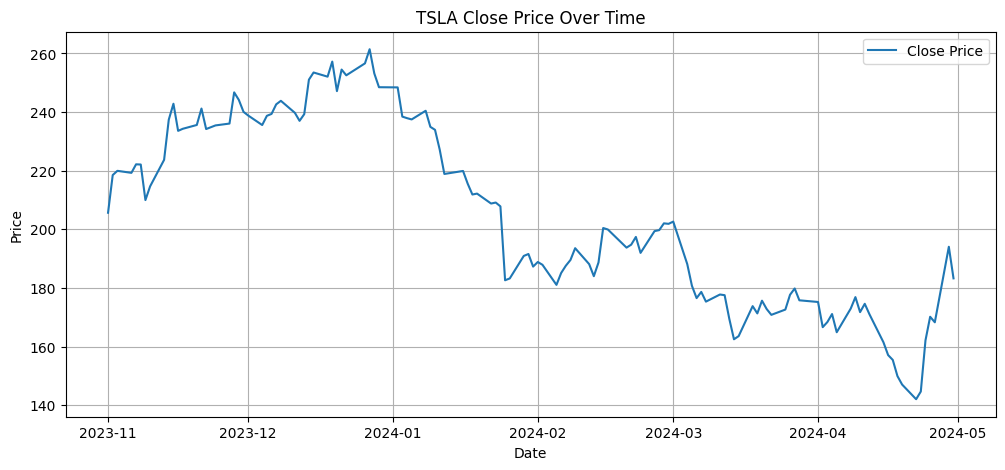

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(data['Date'], data['Close'], label='Close Price')
plt.title('TSLA Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.legend()
plt.show()


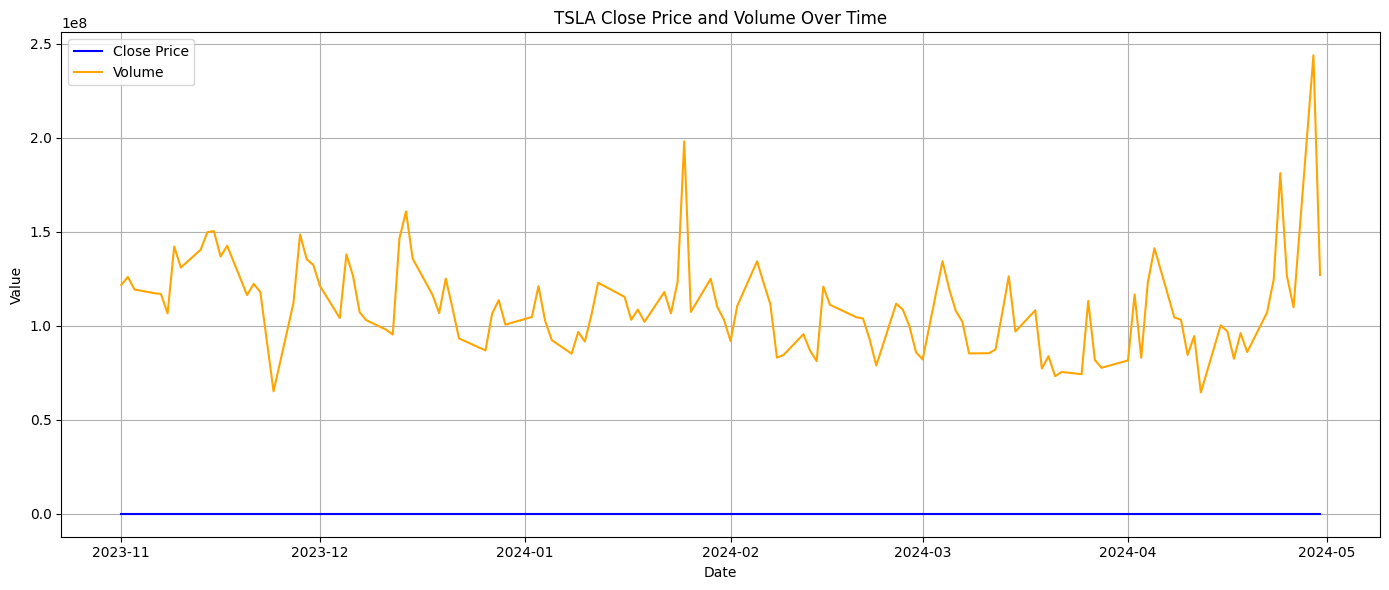

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(data['Date'], data['Close'], label='Close Price', color='blue')
plt.plot(data['Date'], data['Volume'], label='Volume', color='orange')
plt.title('TSLA Close Price and Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


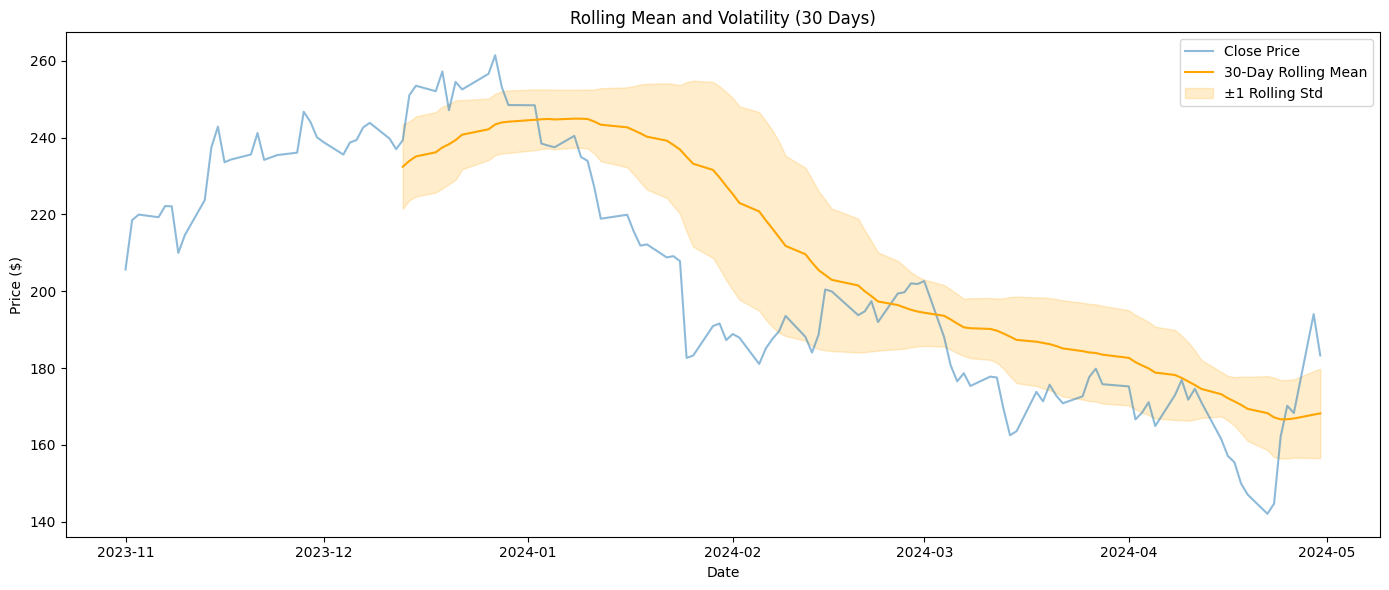

In [ ]:
data['rolling_mean'] = data['Close'].rolling(window=30).mean()
data['rolling_std'] = data['Close'].rolling(window=30).std()

plt.figure(figsize=(14, 6))
plt.plot(data['Date'], data['Close'], label='Close Price', alpha=0.5)
plt.plot(data['Date'], data['rolling_mean'], label='30-Day Rolling Mean', color='orange')
plt.fill_between(data['Date'],
                 data['rolling_mean'] - data['rolling_std'],
                 data['rolling_mean'] + data['rolling_std'],
                 color='orange', alpha=0.2, label='±1 Rolling Std')
plt.title('Rolling Mean and Volatility (30 Days)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.tight_layout()
plt.show()




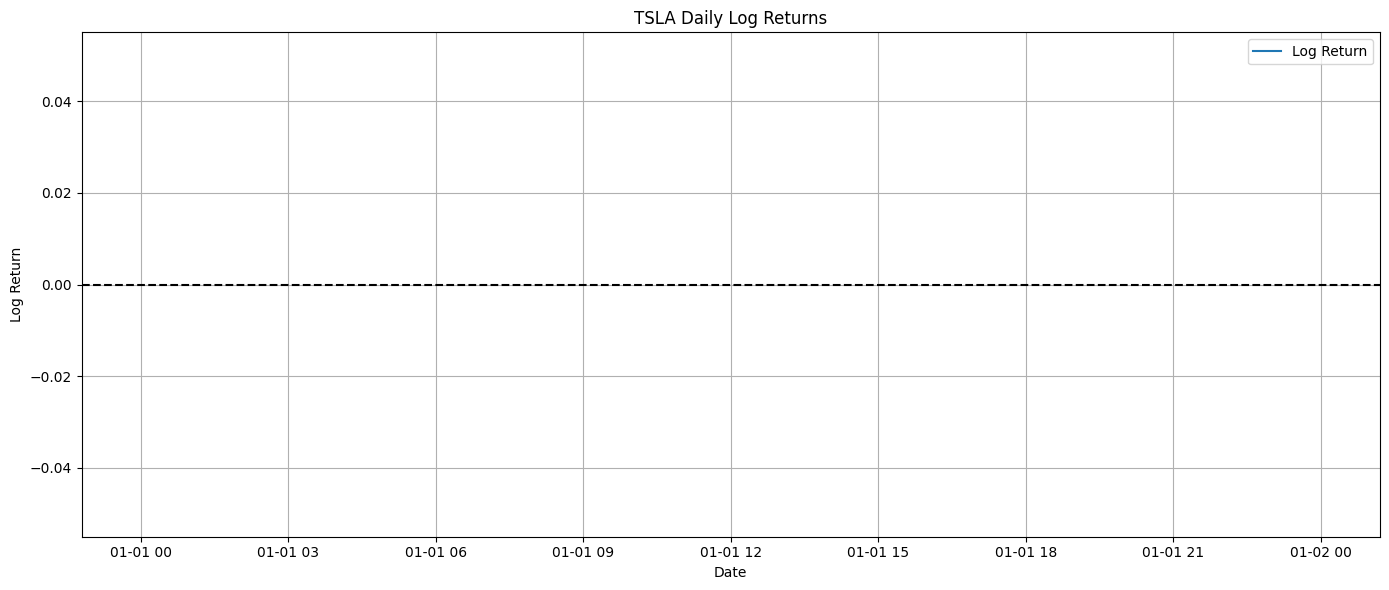

In [ ]:
import numpy as np
import seaborn as sns

# Compute log returns
data['LogReturn'] = np.log(data['Close'] / data['Close'].shift(1))

# Plot log returns
plt.figure(figsize=(14, 6))
sns.lineplot(data=data, x='Date', y='LogReturn', label='Log Return')
plt.axhline(0, color='black', linestyle='--')
plt.title('TSLA Daily Log Returns')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
data.sort_values('Date', inplace=True)
data.reset_index(drop=True, inplace=True)


In [ ]:
# Keep only numerical features you want the model to learn patterns from
features = data[['Open', 'High', 'Low', 'Close', 'Volume']]

# Scale the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Optional: Create a DataFrame for easy inspection
import numpy as np
processed_data = pd.DataFrame(scaled_features, columns=features.columns)
processed_data['Date'] = data['Date'].values

# Show a sample
print(processed_data.head())

Price       Open      High       Low     Close    Volume       Date
Ticker      TSLA      TSLA      TSLA      TSLA      TSLA           
0      -0.007167 -0.062279 -0.078895  0.044881  0.446637 2023-11-01
1       0.276275  0.355410  0.359009  0.454977  0.617825 2023-11-02
2       0.535912  0.582119  0.582790  0.501253  0.352425 2023-11-03
3       0.625737  0.580539  0.473315  0.479232  0.275448 2023-11-06
4       0.498775  0.479357  0.496498  0.572102  0.258206 2023-11-07


In [ ]:
from sklearn.ensemble import IsolationForest

# Model initialization
model = IsolationForest(contamination=0.05, random_state=42)  # Assume 5% of data is anomalous

# Fit the model
model.fit(scaled_features)

# Predict anomalies (-1 = anomaly, 1 = normal)
anomaly_labels = model.predict(scaled_features)

# Add the predictions to the dataframe
processed_data['Anomaly'] = anomaly_labels
processed_data['Anomaly'] = processed_data['Anomaly'].map({1: 0, -1: 1})  # 1 for anomaly

# Show anomalies
anomalies = processed_data[processed_data['Anomaly'] == 1]
print(f"Total anomalies detected: {len(anomalies)}")
print(anomalies.head())


Total anomalies detected: 7
Price       Open      High       Low     Close    Volume       Date Anomaly
Ticker      TSLA      TSLA      TSLA      TSLA      TSLA                   
38      1.716657  1.751081  1.842407  1.825052 -0.153578 2023-12-27       1
39      1.885198  1.807680  1.687532  1.561441  0.128399 2023-12-28       1
115    -1.682745 -1.763076 -1.661466 -1.733696 -0.564962 2024-04-18       1
116    -1.755114 -1.802916 -1.741319 -1.825608 -0.964399 2024-04-19       1
117    -2.022051 -2.008441 -1.980234 -1.985179 -0.129707 2024-04-22       1


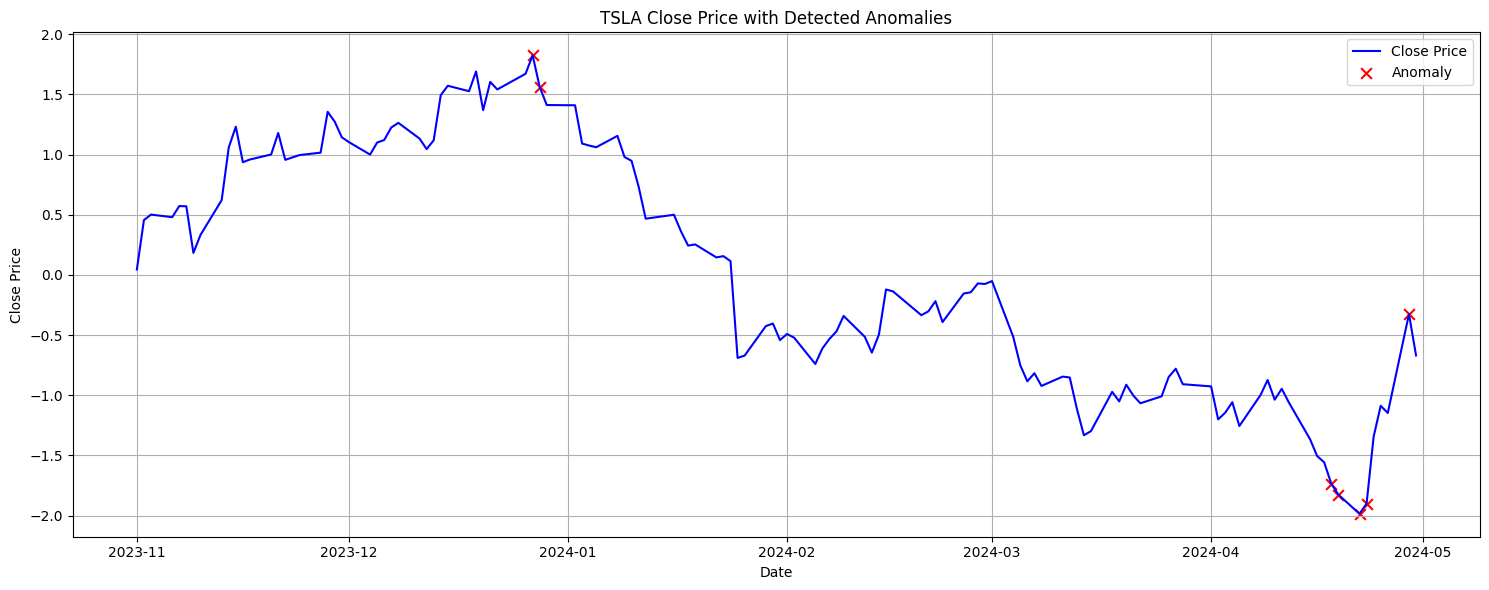

In [ ]:
import matplotlib.pyplot as plt

# Plot setup
plt.figure(figsize=(15, 6))
plt.plot(processed_data['Date'], processed_data['Close'], label='Close Price', color='blue')

# Overlay anomalies
anomalies = processed_data[processed_data['Anomaly'] == 1]
plt.scatter(anomalies['Date'], anomalies['Close'], color='red', label='Anomaly', marker='x', s=60)

# Formatting
plt.title('TSLA Close Price with Detected Anomalies')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
